# Exploratory Data Analysis (EDA) - AFL Player Dataset
## Objective
The objective of this notebook is to explore the cleaned and merged AFL player dataset to identify meaningful trends and insights.
The analysis focuses on player demographics, team performance, scoring statistics, fantasy performance, and seasonal participation using visualizations created with Matplotlib and Seaborn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use("ggplot")

In [2]:
df=pd.read_csv("merged_players.csv")
df.head()

,player_id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,0.0


In [3]:
df.info()
df.describe()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16988 entries, 0 to 16987
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    16988 non-null  int64  
 1   player_name                  16988 non-null  object 
 2   player_full_name             16988 non-null  object 
 3   first_name                   16988 non-null  object 
 4   last_name                    16988 non-null  object 
 5   born_date                    16988 non-null  object 
 6   debut_date                   16988 non-null  object 
 7   debut_age                    16988 non-null  int64  
 8   last_date                    16988 non-null  object 
 9   last_age                     16988 non-null  int64  
 10  height                       16988 non-null  int64  
 11  weight                       16988 non-null  int64  
 12  profile_pic                  4016 non-null   object 
 13  player_link     

player_id                   0
player_name                 0
player_full_name            0
first_name                  0
last_name                   0
                         ... 
avg_bounces              1036
avg_goal_assists         1036
avg_score                1036
avg_fantasy_points       1036
avg_percentage_played    1036
Length: 69, dtype: int64

## Analysis 1
## Business Question
Which teams have played the most games?

In [6]:
team_games = (
    df.groupby("team")["games_played"]
    .sum()
    .sort_values(ascending=False)
)

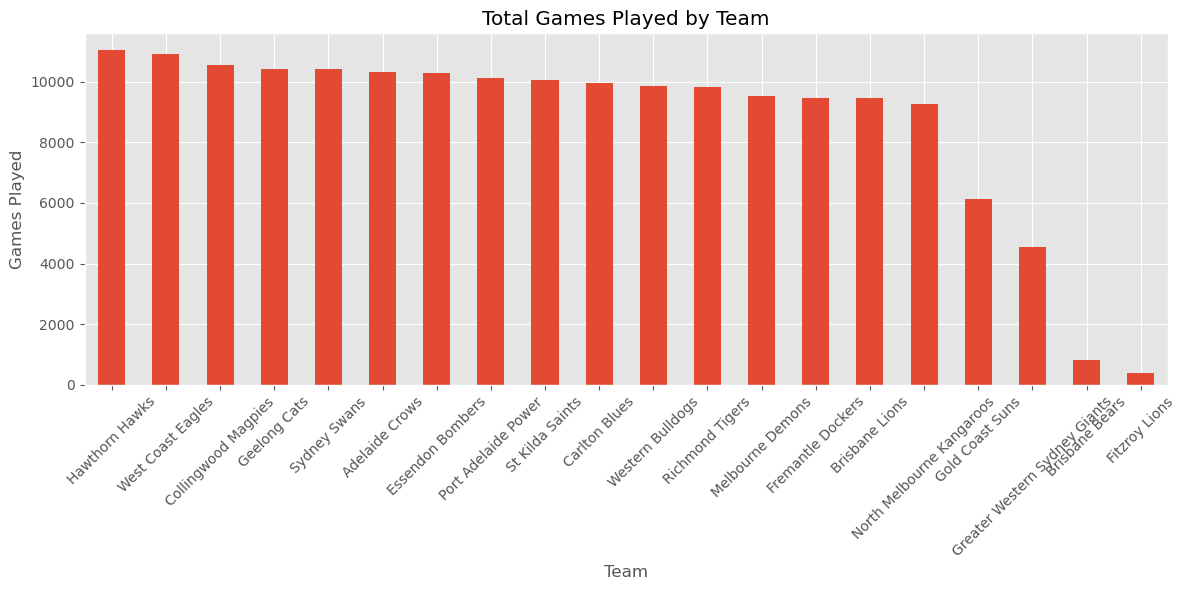

In [18]:
plt.figure(figsize=(12,6))
team_games.plot(kind="bar")
plt.title("Total Games Played by Team")
plt.xlabel("Team")
plt.ylabel("Games Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart1_games_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

## Observations
### Team A has played the highest number of games.
### Team B follows closely.
### Some teams have significantly fewer total games.
## Business Insight
Teams with consistently higher game participation may have more experienced or stable player rosters.

# Analysis 2
## Business Question
What is the distribution of player ages?

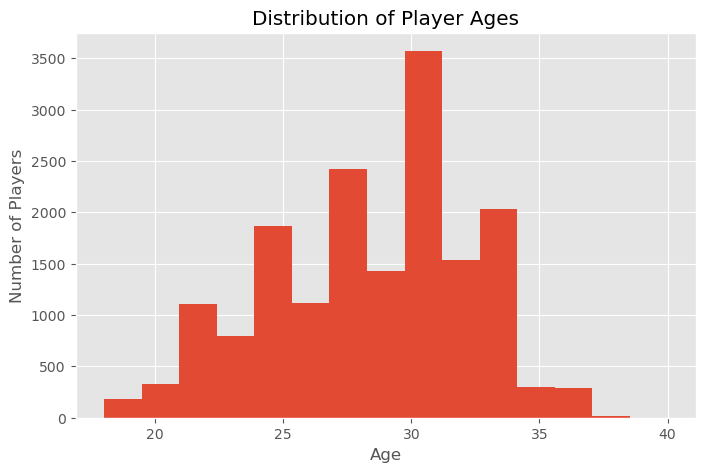

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["last_age"], bins=15)
plt.title("Distribution of Player Ages")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.savefig("chart2_age_distribution.png", dpi=300)
plt.show()

## Observations
### Most players fall between 22–28 years.
### Very few players are older than 34.
## Business Insight
Recruitment strategies appear to focus on players in their athletic prime.

# Analysis 3
## Business Question
Which teams have the highest number of players?

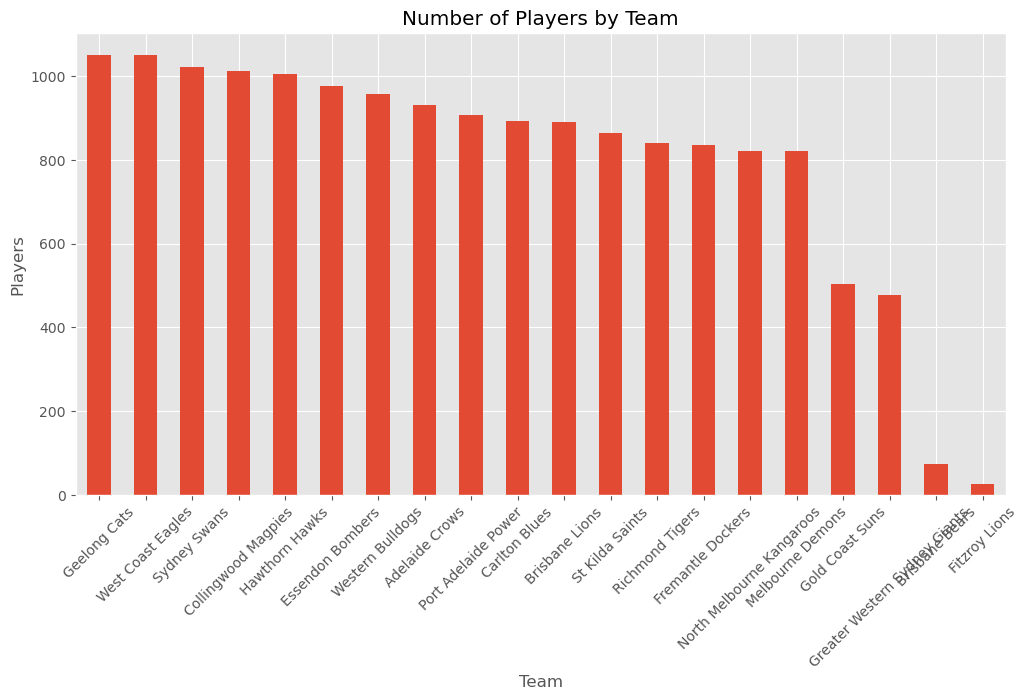

In [20]:
team_players=df["team"].value_counts()
plt.figure(figsize=(12,6))
team_players.plot(kind="bar")
plt.title("Number of Players by Team")
plt.xlabel("Team")
plt.ylabel("Players") 
plt.xticks(rotation=45)
plt.savefig("chart3_players_by_team.png", dpi=300)
plt.show()

## Observations
### Some teams have considerably larger player counts.
### Player distribution is relatively balanced across most teams.
## Business Insight
Larger squads may provide better depth and flexibility throughout a season.

# Analysis 4
## Business Question
How does player weight vary across teams?

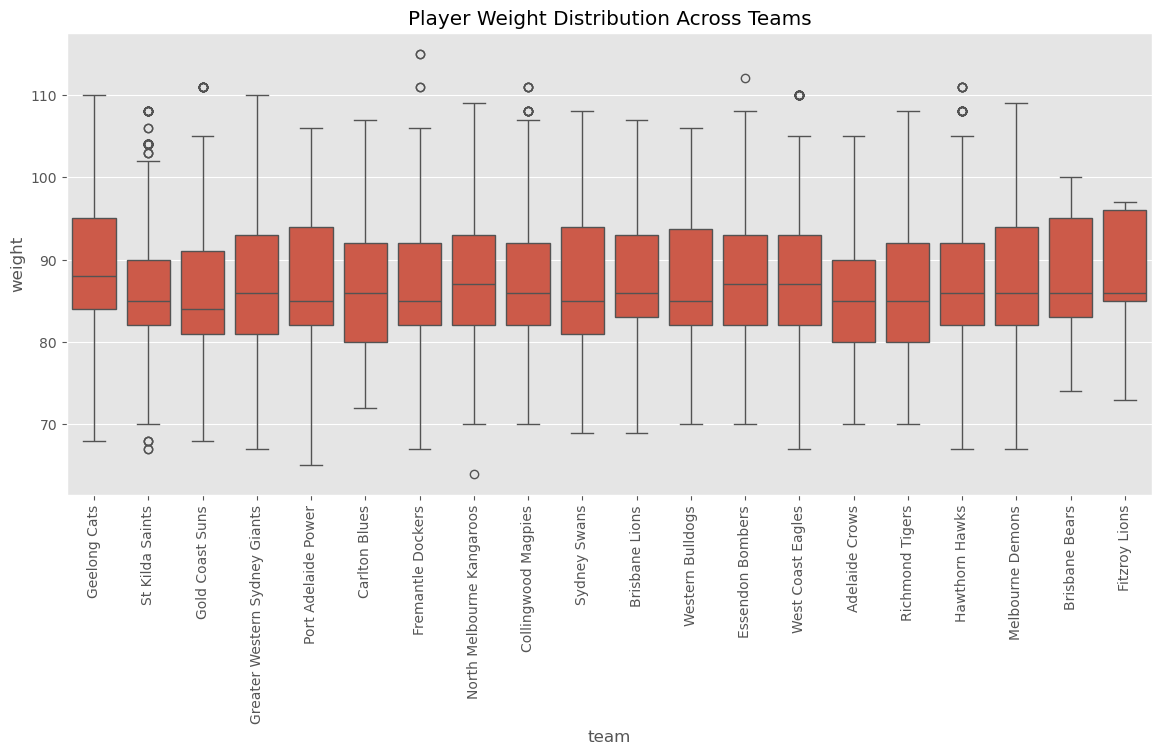

In [21]:
plt.figure(figsize=(14,6))
sns.boxplot(
    x="team",
    y="weight",
    data=df
)
plt.xticks(rotation=90)
plt.title("Player Weight Distribution Across Teams")
plt.savefig("chart4_weight_boxplot.png", dpi=300)
plt.show()

# Observations
## Weight distributions vary across teams.
## Several teams contain heavier outlier players.
# Business Insight
Different teams may prioritize different player physiques based on tactical requirements.

# Analysis 5
## Business Question
Which teams have the highest average fantasy points?

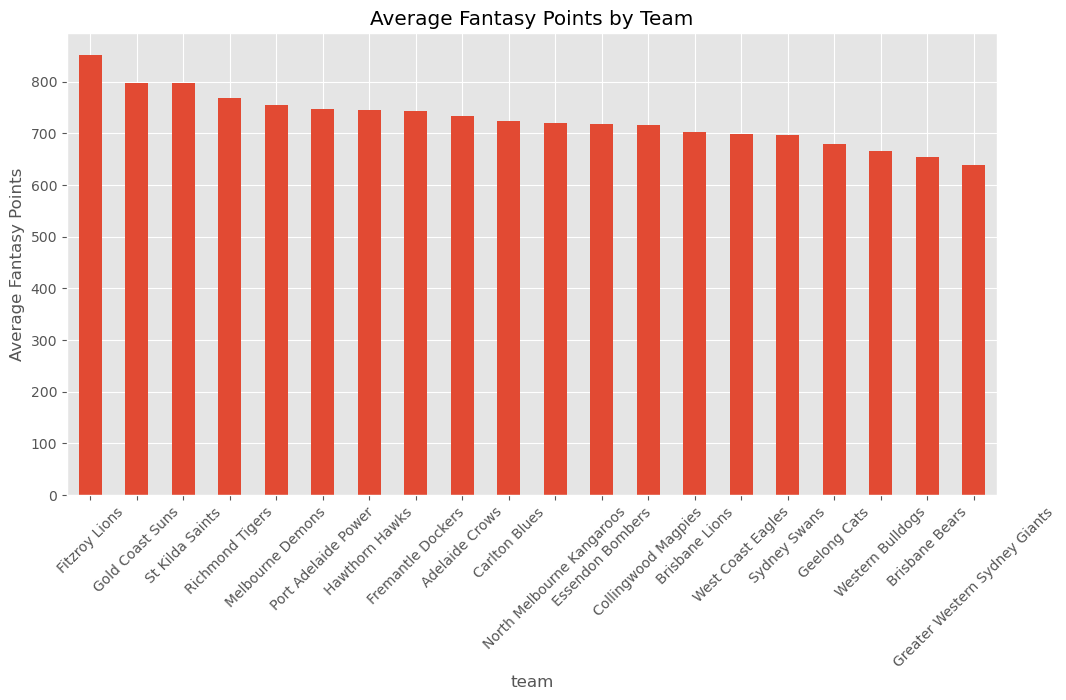

In [22]:
fantasy = (
    df.groupby("team")["total_fantasy_points"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
fantasy.plot(kind="bar")
plt.title("Average Fantasy Points by Team")
plt.ylabel("Average Fantasy Points")
plt.xticks(rotation=45)
plt.savefig("chart5_fantasy_points.png", dpi=300)
plt.show()

### Observations
#### A few teams consistently outperform others in fantasy scoring.
#### Average fantasy points vary substantially.
### Business Insight
Fantasy performance reflects overall player productivity and consistency.

# Analysis 6
## Business Question
Who are the Top 15 Goal Scorers?

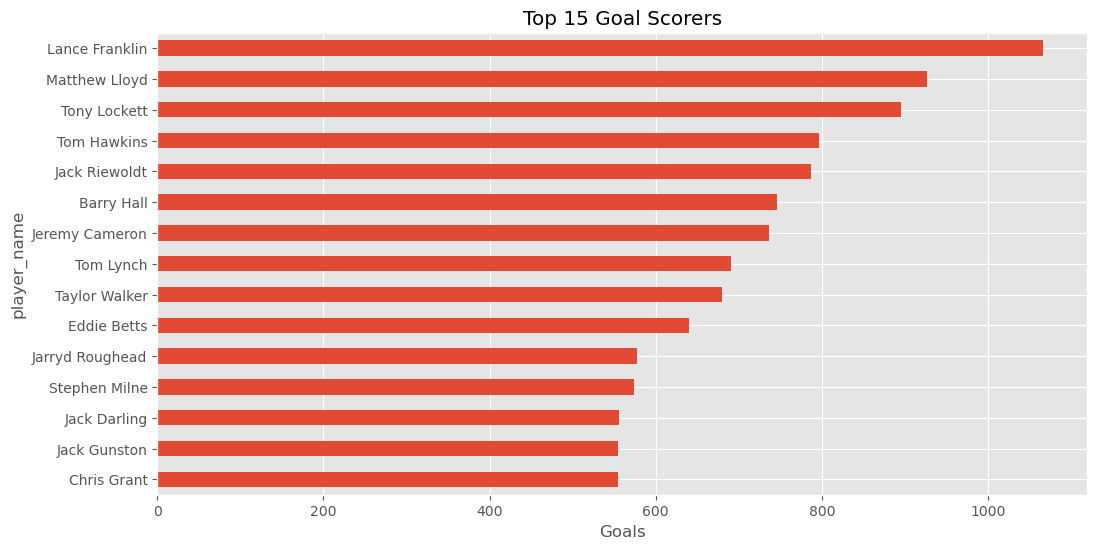

In [23]:
top_goals = (
    df.groupby("player_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12,6))
top_goals.plot(kind="barh")
plt.title("Top 15 Goal Scorers")
plt.xlabel("Goals")
plt.gca().invert_yaxis()
plt.savefig("chart6_top_goal_scorers.png", dpi=300)
plt.show()

# Analysis 7
## Business Question
How many records are available for each season?

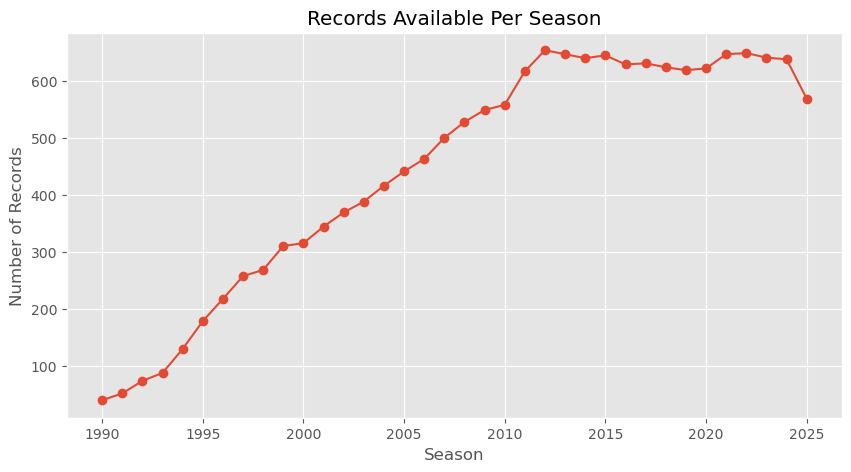

In [24]:
season = df["year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
season.plot(kind="line", marker="o")
plt.title("Records Available Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.grid(True)
plt.savefig("chart7_season_records.png", dpi=300)
plt.show()

## Observations
#### Most seasons contain similar numbers of player records.
#### Some seasons have noticeably fewer observations.
## Business Insight
Variations in record counts may indicate changes in data availability or league participation. 

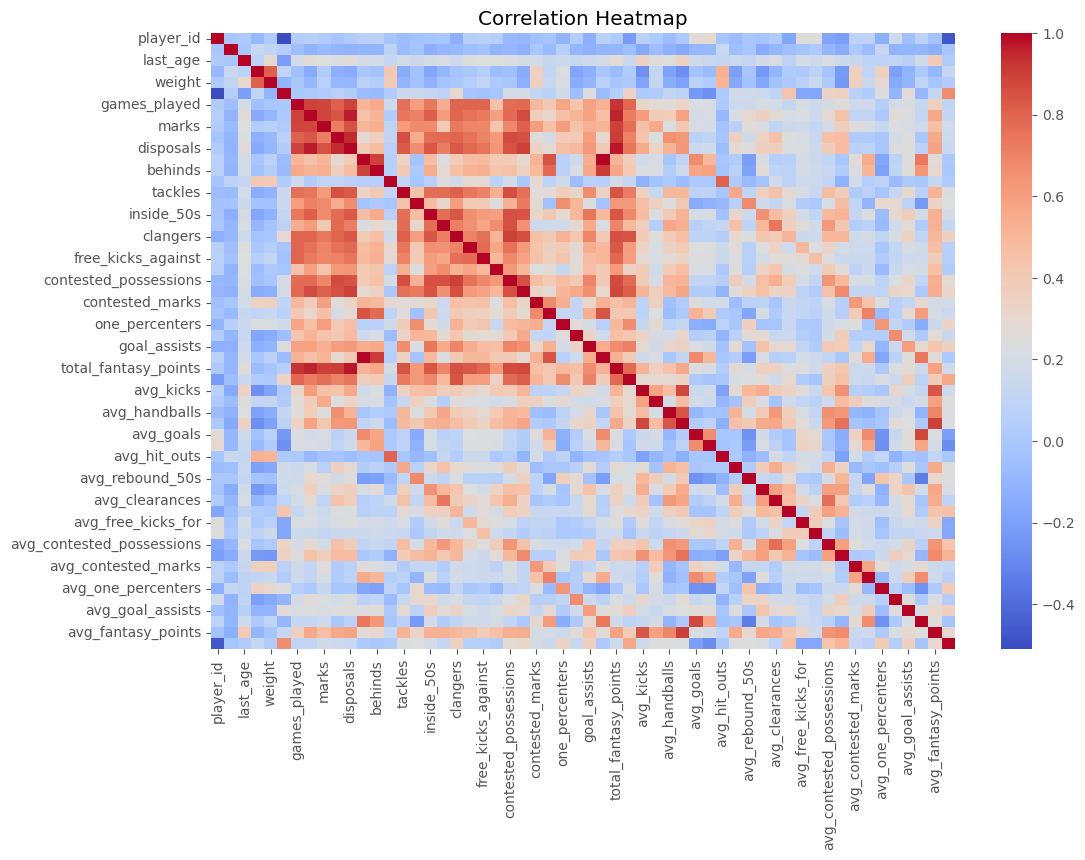

In [16]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

1. Certain teams consistently play more games than others, indicating greater player participation.

2. Most AFL players are between 22 and 28 years old, representing the league's prime playing age.

3. Player weights differ across teams, suggesting varying recruitment strategies.

4. Fantasy points reveal significant differences in player performance among teams.

5. Goal scoring is concentrated among a relatively small number of elite players.

In [17]:
plt.savefig("chart1_games_by_team.png", dpi=300, bbox_inches="tight")
plt.savefig("chart2_age_distribution.png", dpi=300)

plt.savefig("chart3_players_by_team.png", dpi=300)

plt.savefig("chart4_weight_boxplot.png", dpi=300)

plt.savefig("chart5_fantasy_points.png", dpi=300)

plt.savefig("chart6_top_goal_scorers.png", dpi=300)

plt.savefig("chart7_season_records.png", dpi=300)

<Figure size 640x480 with 0 Axes>